In [1]:
# !pip install transformers==4.41.2
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install scikit-learn
# !pip install pandas
# !pip install numpy
# !pip install tqdm
# !pip install scipy
# !pip install huggingface_hub


In [2]:
import json
from typing import List, Dict
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from scipy.stats import pearsonr
from tqdm import tqdm
import math
import re
import requests
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

### Load all the libraries.

### Funtions to transform data

In [3]:
def load_jsonl_url(url):
    """
    Fetches and parses a JSONL file (one JSON object per line) from a URL.
    """
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = [json.loads(line) for line in response.text.strip().split('\n') if line]
        return data
    except Exception as e:
        print(f"Error loading JSONL from {url}: {e}")
        return None

def load_json_url(url):
    """
    Fetches and parses a single, complete JSON file from a URL.
    """
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json() # Use .json() for a single JSON object/list
        return data
    except Exception as e:
        print(f"Error loading JSON from {url}: {e}")
        return None

def transform_sighan_data(external_data, language="zho", domain="restaurant"):
    """
    Transforms the SIGHAN 2024 data structure (a list) into the
    "Quadruplet" format your code expects.
    """
    transformed_data = []

    for entry in external_data:
        quadruplet_list = []

        # Loop through the parallel lists in the SIGHAN data
        for i in range(len(entry["Aspect"])):
            quad = {
                "Aspect": entry["Aspect"][i],
                "Category": entry["Category"][i],
                "Opinion": entry["Opinion"][i],
                "VA": entry["Intensity"][i] # Already in "V#A" format
            }
            quadruplet_list.append(quad)

        # Build the final dictionary in the target format
        new_entry = {
            "ID": entry["ID"],
            "Text": entry["Sentence"], # Map "Sentence" to "Text"
            # "language": language,
            # "domain": domain,
            "Quadruplet": quadruplet_list # This is the key your code expects
        }
        transformed_data.append(new_entry)

    return transformed_data

### Load data

In [4]:
# --- Config ---
subtask = "subtask_1"
task = "task1"
langs = ["eng", "zho", "jpn", "rus", "tat", "ukr"]
# langs = [ "jpn"]
domains = ["restaurant", "laptop","finance","hotel"]

all_train = []
all_dev = []

# --- 1. Load DimABSA 2026 Data (JSONL) ---
print("--- Loading DimABSA 2026 Data ---")
for lang in langs:
    for domain in domains:
        
        if domain=="finance":
            specified_task = "task1"
        else:
            specified_task = "alltasks"
        # specified_task = "alltasks"
        
        train_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_train_{specified_task}.jsonl"
        dev_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_dev_{task}.jsonl"
        try:
            train_raw = load_jsonl_url(train_url) # Use JSONL loader
            if train_raw:
              all_train.extend(train_raw)
              print(f"Loaded DimABSA Train: {lang}-{domain} ✅")

            dev_raw = load_jsonl_url(dev_url) # Use JSONL loader
            if dev_raw:
                all_dev.extend(dev_raw)
                print(f"Loaded DimABSA Dev: {lang}-{domain} ✅")

        except Exception as e:
            print(f"Skipped {lang}-{domain}: {e}")

# # --- 2. Load augmented DimABSA 2026 Data (JSONL) ---
# print("--- Loading augmented DimABSA 2026 Data ---")
# for lang in ["eng"]:
#     for domain in domains:
#         train_url = f"https://raw.githubusercontent.com/hassan09070/SE_Aug_data/refs/heads/main/augmented_{lang}_{domain}_train_alltasks.jsonl"

#         try:
#             train_raw = load_jsonl_url(train_url) # Use JSONL loader
#             if train_raw:
#               all_train.extend(train_raw)
#               print(f"Loaded DimABSA Train: {lang}-{domain} ✅")

#         except Exception as e:
#             print(f"Skipped {lang}-{domain}: {e}")

# --- 2. Load Augmented Gemini English Data (JSONL) ---
print("--- Loading Augmented Gemini Data ---")

augmented_url = "https://raw.githubusercontent.com/hassan09070/SE_Aug_data/refs/heads/main/augmented_eng_gemini_cleaned.jsonl"

def is_valid_va(quadruplets, max_va=9.0):
    """
    Returns False if any quadruplet has valence or arousal > max_va
    """
    for q in quadruplets:
        try:
            valence, arousal = map(float, q["VA"].split("#"))
            if valence > max_va or arousal > max_va:
                return False
        except Exception:
            # Drop malformed VA entries
            return False
    return True

try:
    augmented_raw = load_jsonl_url(augmented_url)

    if augmented_raw:
        kept, removed = 0, 0

        for item in augmented_raw:
            # Remove Language field to keep schema consistent
            item.pop("Language", None)

            # VA-based filtering
            if is_valid_va(item.get("Quadruplet", [])):
                all_train.append(item)
                kept += 1
            else:
                removed += 1

        print(f"Loaded Augmented Gemini Data: {kept} kept, {removed} removed ✅")

except Exception as e:
    print(f"Failed to load augmented data: {e}")


# # --- 3. Load External SIGHAN 2024 Data (JSON) ---
print("\n--- Loading External SIGHAN 2024 Data ---")

sighan_urls = {
    "SIGHAN_Train1": "https://raw.githubusercontent.com/NYCU-NLP/SIGHAN2024-dimABSA/refs/heads/main/DataSets/dimABSA2024/Simplified/SIGHAN2024_dimABSA_TrainingSet1_Simplified.json",
    "SIGHAN_Train2": "https://raw.githubusercontent.com/NYCU-NLP/SIGHAN2024-dimABSA/refs/heads/main/DataSets/dimABSA2024/Simplified/SIGHAN2024_dimABSA_TrainingSet2_Simplified.json"
}

for name, url in sighan_urls.items():
    try:
        print(f"Fetching and processing {name}...")

        # 1. Fetch the raw data (it's a JSON file)
        external_raw_data = load_json_url(url) # Use NEW JSON loader

        if external_raw_data:
            # 2. Transform the raw data directly in memory
            external_transformed_data = transform_sighan_data(
                external_data=external_raw_data,
                # language="zho",
                # domain="restaurant" # SIGHAN data is restaurant domain
            )

            # 3. Add the new data to the main training list
            all_train.extend(external_transformed_data)
            print(f"Successfully added {len(external_transformed_data)} items from {name}.")

    except Exception as e:
        print(f"Failed to load or transform external data from {name}: {e}")

# --- Summary ---
print("\n--- Data Loading Complete ---")
print(f"Total training samples: {len(all_train)}")
print(f"Total dev (prediction) samples: {len(all_dev)}")


#model config
model_name = "microsoft/mdeberta-v3-base" # chage your transformer model
# model_name = "xlm-roberta-large" 3done
# model_name = "bert-base-multilingual-cased" #done
# model_name = "xlm-roberta-base" #done
repo_name = "mdeberta-v3-base"
lr = 2e-5 #learning rate
epochs = 10
BATCH_SIZE=16

print(model_name)

--- Loading DimABSA 2026 Data ---
Loaded DimABSA Train: eng-restaurant ✅
Loaded DimABSA Dev: eng-restaurant ✅
Loaded DimABSA Train: eng-laptop ✅
Loaded DimABSA Dev: eng-laptop ✅
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_hotel_train_alltasks.jsonl

Total datapoints        : 32980
Total quadruplets       : 45319
Malformed VA skipped    : 0


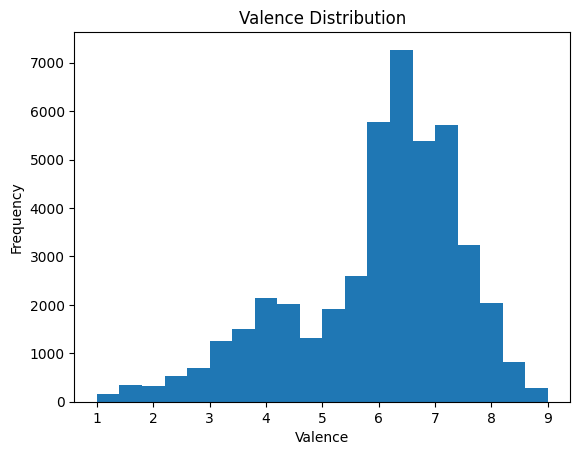

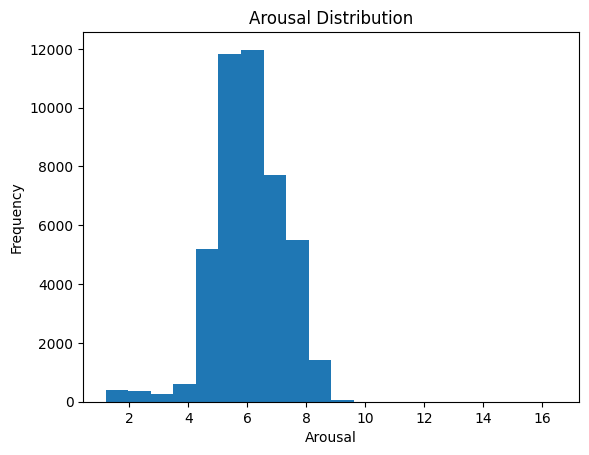

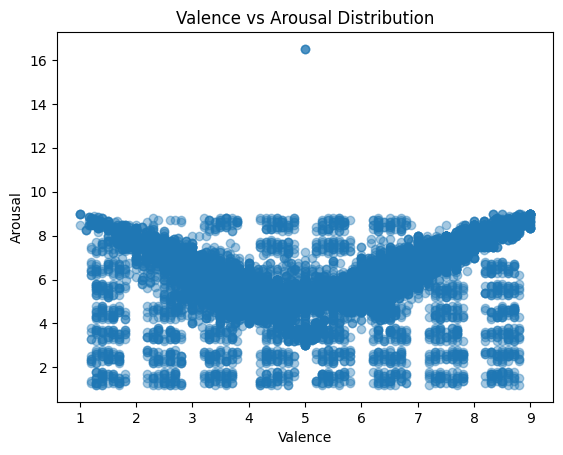

Valence Stats : {'min': 1.0, 'max': 9.0, 'mean': 5.972687393808336}
Arousal Stats : {'min': 1.2, 'max': 16.5, 'mean': 6.089083386659017}


In [5]:
# --- Analyze Valence & Arousal Distribution ---
import matplotlib.pyplot as plt

# Collect VA values
valences = []
arousals = []
total_quads = 0
skipped = 0

all_data = []
if "all_train" in globals():
    all_data.extend(all_train)
if "all_dev" in globals():
    all_data.extend(all_dev)

for item in all_data:
    for q in item.get("Quadruplet", []):
        try:
            v, a = map(float, q["VA"].split("#"))
            valences.append(v)
            arousals.append(a)
            total_quads += 1
        except Exception:
            skipped += 1

print(f"Total datapoints        : {len(all_data)}")
print(f"Total quadruplets       : {total_quads}")
print(f"Malformed VA skipped    : {skipped}")

# ---- Plot Valence Distribution ----
plt.figure()
plt.hist(valences, bins=20)
plt.xlabel("Valence")
plt.ylabel("Frequency")
plt.title("Valence Distribution")
plt.show()

# ---- Plot Arousal Distribution ----
plt.figure()
plt.hist(arousals, bins=20)
plt.xlabel("Arousal")
plt.ylabel("Frequency")
plt.title("Arousal Distribution")
plt.show()

# ---- Joint Scatter Plot ----
plt.figure()
plt.scatter(valences, arousals, alpha=0.4)
plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("Valence vs Arousal Distribution")
plt.show()

# ---- Basic Statistics ----
def stats(x):
    return {
        "min": min(x),
        "max": max(x),
        "mean": sum(x) / len(x)
    }

print("Valence Stats :", stats(valences))
print("Arousal Stats :", stats(arousals))


###Convert data to dataframes and split

In [6]:
def normalize_list_keys(data_list):
    """
    Standardizes a list of dicts so EVERY entry has a 'Quadruplet' key.
    Correctly handles Task 1 input (list of Aspect strings).
    """
    normalized = []
    for entry in data_list:
        # Create a copy to avoid modifying the original list in place
        new_entry = entry.copy()
        
        # 1. Find the data
        items = []
        if 'Quadruplet' in new_entry:
            items = new_entry.pop('Quadruplet')
        elif 'Triplet' in new_entry:
            items = new_entry.pop('Triplet')
        elif 'Aspect_VA' in new_entry:
            items = new_entry.pop('Aspect_VA')
        elif 'Aspect' in new_entry:
            aspect_data = new_entry.pop('Aspect')
            # --- FIX: Handle list of strings (Task 1 Input) ---
            if isinstance(aspect_data, list):
                # Transform ["food", "service"] -> [{"Aspect": "food"}, {"Aspect": "service"}]
                items = [{'Aspect': a, 'VA': '5.0#5.0'} for a in aspect_data]
            else:
                # Handle single string case
                items = [{'Aspect': aspect_data, 'VA': '5.0#5.0'}]
        
        # 2. Standardize the list items
        # We ensure every item has all 4 keys, filling missing ones with NULL
        safe_items = []
        if isinstance(items, list):
            for item in items:
                # Handle case where item might be a string (rare edge case)
                if isinstance(item, str):
                    item = {'Aspect': item}
                    
                safe_items.append({
                    "Aspect": item.get("Aspect", "NULL"),
                    "Category": item.get("Category", "NULL"),
                    "Opinion": item.get("Opinion", "NULL"),
                    "VA": item.get("VA", "5.0#5.0") # Default VA prevents KeyError
                })
        
        # 3. Set the standard key
        new_entry['Quadruplet'] = safe_items
        normalized.append(new_entry)
        
    return normalized

# --- RERUN NORMALIZATION ---
print("Re-normalizing data keys...")
all_train_normalized = normalize_list_keys(all_train)
all_dev_normalized = normalize_list_keys(all_dev)
print("✅ Data normalized. Now you can run jsonl_to_df.")

Re-normalizing data keys...
✅ Data normalized. Now you can run jsonl_to_df.


In [7]:
#==== step 1 load the data ====
# you can change the env for your task.
# train data should have the VA labels, predit data without VA labels

def jsonl_to_df(data):
    if 'Quadruplet' in data[0]:
        df = pd.json_normalize(data, 'Quadruplet', ['ID', 'Text'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA', 'Category', 'Opinion'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Triplet' in data[0]:
        df = pd.json_normalize(data, 'Triplet', ['ID', 'Text'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA', 'Opinion'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Aspect' in data[0]:
        df = pd.json_normalize(data, 'Aspect', ['ID', 'Text'])
        df = df.rename(columns={df.columns[0]: "Aspect"})  # rename to Aspect
        df['Valence'] = 0  # default value
        df['Arousal'] = 0  # default value
   
    elif 'Aspect_VA' in data[0]:
        df = pd.json_normalize(data, 'Aspect_VA', ['ID', 'Text'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect
    else:
        raise ValueError("Invalid format: must include 'Quadruplet' or 'Triplet' or 'Aspect'")

    return df

train_df = jsonl_to_df(all_train_normalized)
predict_df = jsonl_to_df(all_dev_normalized)


# split 10% for dev
train_df, dev_df = train_test_split(train_df, test_size=0.1, random_state=42)

###Display the dataframes

In [8]:
from IPython.display import display, Markdown

display(Markdown(f"###train_df"))
display(train_df.head())

display(Markdown(f"###dev_df"))
display(dev_df.head())

display(Markdown(f"###predict_df"))
display(predict_df.head())

###train_df

,Aspect,ID,Text,Valence,Arousal
18778,價格,6868362:S004,Vivobook的定位其實比較是輕薄創作者筆電，要滿血要玩遊戲還是推TUF，價格也差不多想輕...,4.83,5.00
6176,NULL,laptop_quad_train_658,laptop meets spec for what it was purchased to...,2.75,7.50
35908,хезмәт күрсәтүне,21574:3_902,"Аерым рәхмәт, андый хезмәт күрсәтүне күптән кү...",7.38,6.88
6874,computer,laptop_quad_train_1179,the computer itself is as stated and i receive...,7.62,7.75
31964,порции,2616:5_185,Все порции внушительного размера:),7.17,6.50


###dev_df

,Aspect,ID,Text,Valence,Arousal
30329,接客,hotel_quad_train_839,従業員の方の接客がとても良く楽しい気持ちで旅を楽しめました,7.12,6.75
45896,店家态度,R2894:S010,不过料特别多就是了，但其实店家态度没到很好。,4.50,5.33
41024,laptop price,aug_synth_groq_eng_17684271662507_7268,I'm satisfied with the laptop's affordable pri...,8.70,5.40
28414,生鮮食品,finance_aspect_va_train_806,食品部門では、バナナ等の生鮮食品の売上高は堅調に推移したものの、ナッツ・ドライフルーツ等の加...,5.83,5.00
48168,樱桃霸王鸭五吃,R3102:S038,红楼中餐厅这个樱桃霸王鸭五吃的套餐以四个人吃来说真的不贵。,6.62,6.25


###predict_df

,Aspect,ID,Text,Valence,Arousal
0,diner food,rest26_aspect_va_dev_1,Great diner food and breakfast is served all day,5.0,5.0
1,breakfast,rest26_aspect_va_dev_1,Great diner food and breakfast is served all day,5.0,5.0
2,food,rest26_aspect_va_dev_2,It got very crowded but we still received exce...,5.0,5.0
3,drinks,rest26_aspect_va_dev_2,It got very crowded but we still received exce...,5.0,5.0
4,service,rest26_aspect_va_dev_2,It got very crowded but we still received exce...,5.0,5.0


###Build Dataset and DataLoader

In [9]:
#==== Dataset ====
class VADataset(Dataset):
    '''
    A PyTorch Dataset for Valence–Arousal regression with language + domain context.

    - Combines language, domain, aspect, and text into a single input:
        e.g., "[ENG] [LAPTOP] keyboard: The keyboard is good"
    - Tokenizes the input using a HuggingFace tokenizer.
    - Returns:
        * input_ids: token IDs, shape [max_len]
        * attention_mask: mask, shape [max_len]
        * labels: [Valence, Arousal], shape [2], float tensor

    Args:
        dataframe (pd.DataFrame): must contain columns
            "Text", "Aspect", "Valence", "Arousal", "language", "domain".
        tokenizer: HuggingFace tokenizer.
        max_len (int): max sequence length.
    '''
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.sentences = dataframe["Text"].tolist()
        self.aspects = dataframe["Aspect"].tolist()
        self.labels = dataframe[["Valence", "Arousal"]].values.astype(float)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):

        text = f"[{lang}] [{domain}] {self.aspects[idx]}: {self.sentences[idx]}"

        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }



# convert to Dataset and Dataloader
tokenizer = AutoTokenizer.from_pretrained(model_name,use_fast=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = VADataset(train_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

dev_dataset = VADataset(dev_df, tokenizer)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=True)


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

In [10]:
import torch
print(torch.cuda.is_available())  # Should be True
print(torch.cuda.device_count())  # Number of GPUs
print(torch.cuda.get_device_name(0))  # GPU name


True
2
Tesla T4


###Build TransformerVARegressor


In [ ]:
#====step 3 build your model ====
class TransformerVARegressor(nn.Module):
    '''
    A BERT-based regressor for predicting Valence and Arousal scores.

    - Uses a pretrained BERT backbone to encode text.
    - Takes the [CLS] token representation as sentence-level embedding.
    - Adds a dropout layer and a linear head to output 2 values: [Valence, Arousal].
    - Includes helper methods for one training epoch and one evaluation epoch.

    Args:
        model_name (str): HuggingFace model name, default "bert-base-multilingual-cased".
        dropout (float): Dropout rate before the regression head.

    Methods:
        train_epoch(dataloader, optimizer, loss_fn, device):
            Train the model for one epoch.
            Returns average training loss.

        eval_epoch(dataloader, loss_fn, device):
            Evaluate the model for one epoch (no gradient).
            Returns average validation loss.
    '''
    def __init__(self, model_name=model_name, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
         # --- SIGHAN PAPER FIX ---
        self._disable_backbone_dropout()
        # ------------------------
        self.dropout = nn.Dropout(dropout)
        self.reg_head = nn.Linear(self.backbone.config.hidden_size, 2)  # Valence + Arousal
    def _disable_backbone_dropout(self):
        """
        Finds all nn.Dropout modules in the backbone and sets their
        dropout probability to 0. This is the fix from the paper.
        """
        count = 0
        for module in self.backbone.modules():
            if isinstance(module, nn.Dropout):
                module.p = 0.0 # Set dropout probability to zero
                count += 1


    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]  # [CLS] token
        x = self.dropout(cls_output)
        return self.reg_head(x)


    def train_epoch(self, dataloader, optimizer, loss_fn, device, scheduler):
        self.train()
        total_loss = 0
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = self(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)

             # Use the scaler to backpropagate
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)

            # --- SIMPLIFIED: Step every batch ---
            optimizer.step()
            scheduler.step() # Step scheduler *with* optimizer

            total_loss += loss.item()
        return total_loss / len(dataloader)

    def eval_epoch(self, dataloader, loss_fn, device):
        self.eval()
        total_loss = 0
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = self(input_ids, attention_mask)
                loss = loss_fn(outputs, labels)
                total_loss += loss.item()
        return total_loss / len(dataloader)


def concordance_correlation_coefficient(y_true, y_pred, eps=1e-8):
    mean_true = torch.mean(y_true)
    mean_pred = torch.mean(y_pred)

    var_true = torch.var(y_true, unbiased=False)
    var_pred = torch.var(y_pred, unbiased=False)

    cov = torch.mean((y_true - mean_true) * (y_pred - mean_pred))

    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred)**2 + eps)

    # optional but safe
    ccc = torch.clamp(ccc, -1.0, 1.0)

    return ccc


class CCCMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, outputs, labels):
        loss_v = 0.5 * self.mse(outputs[:, 0], labels[:, 0]) \
               + 0.5 * (1 - concordance_correlation_coefficient(labels[:, 0], outputs[:, 0]))

        loss_a = 0.5 * self.mse(outputs[:, 1], labels[:, 1]) \
               + 0.5 * (1 - concordance_correlation_coefficient(labels[:, 1], outputs[:, 1]))

        return loss_v + loss_a


### Training the model

In [ ]:
from transformers import get_linear_schedule_with_warmup # Better scheduler
# Training bert on your data
model = TransformerVARegressor().to(device)
model.backbone.resize_token_embeddings(len(tokenizer))
lr = locals().get("lr", 2e-5 )
epochs = locals().get("epochs", 1)

BEST_MODEL_PATH = f"/kaggle/working/best_model.bin" # Define a save path
# BEST_MODEL_PATH = "/content/best_model.bin" #for colab

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
loss_fn = CCCMSELoss()

# Add learning rate scheduler and early stopping
num_training_steps = epochs * len(train_loader)
num_warmup_steps = int(num_training_steps * 0.1) # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 5 # Define patience for early stopping

# Lists to store losses for elbow analysis
train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = model.train_epoch(train_loader, optimizer, loss_fn, device, scheduler)
    val_loss = model.eval_epoch(dev_loader, loss_fn, device)

    print(f"model:{model_name} Epoch:{epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    # Store losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # --- FIX: Actually save the best model ---
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved to {BEST_MODEL_PATH} with Val Loss: {best_val_loss:.4f}")

    else:
        patience_counter += 1
        print(f"  (Patience counter: {patience_counter}/{early_stopping_patience})")
        if patience_counter >= early_stopping_patience:
            print(f"--- Early stopping after {early_stopping_patience} epochs without improvement. ---")
            break

2026-01-16 16:16:42.971490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768580203.178052      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768580203.239419      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768580203.769622      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768580203.769676      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768580203.769678      23 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]


100%|██████████| 2264/2264 [20:24<00:00,  1.85it/s]


model:microsoft/mdeberta-v3-base Epoch:1: train=2.6422, val=0.5362
New best model saved to /kaggle/working/best_model.bin with Val Loss: 0.5362


...

model:microsoft/mdeberta-v3-base Epoch:8: train=0.0591, val=0.2874
  (Patience counter: 1/5)


100%|██████████| 2264/2264 [20:24<00:00,  1.85it/s]


model:microsoft/mdeberta-v3-base Epoch:9: train=0.0452, val=0.2800
New best model saved to /kaggle/working/best_model.bin with Val Loss: 0.2800


100%|██████████| 2264/2264 [20:24<00:00,  1.85it/s]


model:microsoft/mdeberta-v3-base Epoch:10: train=0.0358, val=0.2809
  (Patience counter: 1/5)


### Elbow Analysis: Training and Validation Loss

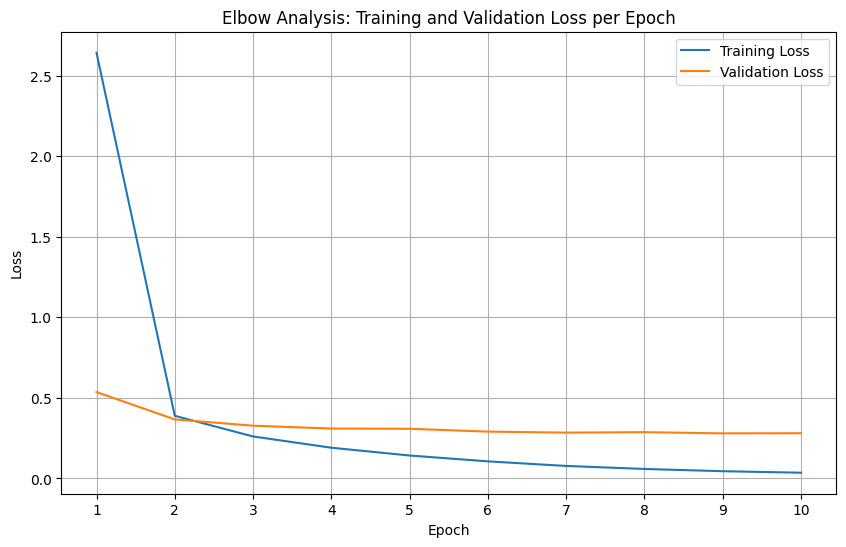

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Elbow Analysis: Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(range(1, len(train_losses) + 1))
plt.show()

###Evaluate model performance on dev set


In [14]:
#==== step 4 use dev data to check your model's performance ====
def get_prd(model,dataloder, type ="dev"):
    if type == "dev":
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in dataloder:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].cpu().numpy()
                outputs = model(input_ids, attention_mask).cpu().numpy()
                all_preds.append(outputs)
                all_labels.append(labels)
        preds = np.vstack(all_preds)
        lables = np.vstack(all_labels)

        pred_v = preds[:,0]
        pred_a = preds[:,1]

        gold_v = lables[:,0]
        gold_a = lables[:,1]

        return pred_v, pred_a, gold_v, gold_a

    elif type == "pred":
        all_preds = []
        with torch.no_grad():
            for batch in dataloder:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask).cpu().numpy()
                all_preds.append(outputs)
        preds = np.vstack(all_preds)

        pred_v = preds[:, 0]
        pred_a = preds[:, 1]

        return pred_v, pred_a

def evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v):
    if not (all(1 <= x <= 9 for x in pred_v) and all(1 <= x <= 9 for x in pred_a)):
        print(f"Warning: Some predicted values are out of the numerical range.")
    pcc_v = pearsonr(pred_v, gold_v)[0]
    pcc_a = pearsonr(pred_a, gold_a)[0]

    gold_va = gold_v + gold_a
    pred_va = pred_v + pred_a

    def rmse(gold_va, pred_va):
        result = [(a - b) ** 2 for a, b in zip(gold_va, pred_va)]
        return math.sqrt(sum(result)/len(gold_v))

    rmse_va = rmse(gold_va, pred_va)
    return {
        'PCC_V': pcc_v,
        'PCC_A': pcc_a,
        'RMSE_VA': rmse_va,
    }

# lap dev score
pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader,type="dev")
eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
print(f"{model_name} dev_eval: {eval_score}")

microsoft/mdeberta-v3-base dev_eval: {'PCC_V': np.float32(0.9368653), 'PCC_A': np.float32(0.881865), 'RMSE_VA': 0.8440462934399188}


In [15]:
predict_raw ={}
train_raw={}
task = "task1"
for lang in langs:
    for domain in domains:
        
        if domain=="finance":
            specified_task = "task1"
        else:
            specified_task = "alltasks"
        # specified_task = "alltasks"
        
        train_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_train_{specified_task}.jsonl"
        predict_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_dev_{task}.jsonl"

        key = f"{lang}_{domain}"
        raw_train_data = load_jsonl_url(train_url)
        if raw_train_data:
            train_raw[key] = raw_train_data
            print(f"Loaded Train: {key}")
        else:
            print(f"Skipped Train: {key}")
            
        raw_predict_data = load_jsonl_url(predict_url)
        if raw_predict_data:
            
            predict_raw[key] = raw_predict_data
            print(f"Loaded Predict: {key}")
        else:
            print(f"Skipped Predict: {key}")



predict_df={}
train_df={}
dev_df={}
for lang in langs:
    for domain in domains:
        try:
            train_df[lang+"_"+domain] = jsonl_to_df(train_raw[lang+"_"+domain])
            predict_df[lang+"_"+domain] = jsonl_to_df(predict_raw[lang+"_"+domain])
            train_df[lang+"_"+domain], dev_df[lang+"_"+domain] = train_test_split(train_df[lang+"_"+domain], test_size=0.1, random_state=42)
        except KeyError:
            continue



for lang in langs:
    for domain in domains:
      try:
          display(Markdown(f"### {subtask}_{lang}_{domain} train_df"))
          display(train_df[lang+"_"+domain].head())
    
          display(Markdown(f"### {subtask}_{lang}_{domain} dev_df"))
          display(dev_df[lang+"_"+domain].head())
    
          display(Markdown(f"### {subtask}_{lang}_{domain} predict_df"))
          display(predict_df[lang+"_"+domain].head())
      except:
          continue

dev_dataset={}
dev_loader={}
for lang in langs:
    for domain in domains:
      try:
        dev_dataset[lang+"_"+domain] = VADataset(dev_df[lang+"_"+domain], tokenizer)
        dev_loader[lang+"_"+domain] = DataLoader(dev_dataset[lang+"_"+domain], batch_size=64, shuffle=False)
      except KeyError:
        print("not found")


Loaded Train: eng_restaurant
Loaded Predict: eng_restaurant
Loaded Train: eng_laptop
Loaded Predict: eng_laptop
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl
Skipped Train: eng_finance
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl
Skipped Predict: eng_finance
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_hotel_train_alltasks.jsonl: 404 Clie

### subtask_1_eng_restaurant train_df

,Aspect,ID,Text,Valence,Arousal
481,winelist,rest16_quad_test_127,seattle ' s best winelist,8.25,8.38
2520,veal,rest16_quad_train_814,"the restaurant has a family feel , not least w...",5.67,5.33
3067,bathroom,rest16_quad_train_1157,"service ok but unfriendly , filthy bathroom .",3.33,5.83
667,crab cakes,rest16_quad_test_222,best crab cakes in town,6.88,6.50
2462,NULL,rest16_quad_train_781,they are not helpful in the least and will giv...,3.17,7.00


### subtask_1_eng_restaurant dev_df

,Aspect,ID,Text,Valence,Arousal
172,NULL,rest16_quad_dev_118,way below average,2.67,7.00
351,pizza place,rest16_quad_test_53,mama mia – i live in the neighborhood and feel...,7.88,8.00
3132,cocktail with citrus vodka and lemon and lime ...,rest16_quad_train_1191,the have a great cocktail with citrus vodka an...,7.88,8.12
1993,place,rest16_quad_train_499,not a great place for family or general dining .,3.00,6.75
366,food,rest16_quad_test_64,"the food is great , the bartenders go that ext...",7.67,7.50


...

,Aspect,ID,Text,Valence,Arousal
0,хінкалі,354:12_0,"Блюдо хінкалі складається з 4 штук, хороших ро...",0,0
1,музика,1180:1_1,"Дуже все сподобалося, музика ненав'язлива, дів...",0,0
2,дівчина,1180:1_1,"Дуже все сподобалося, музика ненав'язлива, дів...",0,0
3,порції,1180:1_1,"Дуже все сподобалося, музика ненав'язлива, дів...",0,0
4,страви,1206:8_2,Плюс страви цілком зрозумілі (я б сказав трохи...,0,0


### subtask_1_ukr_laptop train_df

### subtask_1_ukr_finance train_df

### subtask_1_ukr_hotel train_df

not found
not found
not found
not found
not found
not found
not found
not found
not found
not found
not found
not found
not found
not found


In [16]:
# lap dev score
for lang in langs:
    for domain in domains:
        try:
          pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader[lang+"_"+domain],type="dev")
          eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
          print(f"{lang}_{domain} dev_eval: {eval_score}")
        except:
          continue

eng_restaurant dev_eval: {'PCC_V': np.float32(0.9825547), 'PCC_A': np.float32(0.9439697), 'RMSE_VA': 0.5448756591449837}
eng_laptop dev_eval: {'PCC_V': np.float32(0.99189967), 'PCC_A': np.float32(0.9709402), 'RMSE_VA': 0.3736375655865485}
zho_restaurant dev_eval: {'PCC_V': np.float32(0.9864819), 'PCC_A': np.float32(0.96057296), 'RMSE_VA': 0.2630575016006364}
zho_laptop dev_eval: {'PCC_V': np.float32(0.9806056), 'PCC_A': np.float32(0.968035), 'RMSE_VA': 0.3250855956700889}
zho_finance dev_eval: {'PCC_V': np.float32(0.96030104), 'PCC_A': np.float32(0.90798867), 'RMSE_VA': 0.2887357979126356}
jpn_finance dev_eval: {'PCC_V': np.float32(0.9935299), 'PCC_A': np.float32(0.9570179), 'RMSE_VA': 0.21676716300194904}
jpn_hotel dev_eval: {'PCC_V': np.float32(0.9882721), 'PCC_A': np.float32(0.9475161), 'RMSE_VA': 0.25897397326816335}
rus_restaurant dev_eval: {'PCC_V': np.float32(0.9953367), 'PCC_A': np.float32(0.9816692), 'RMSE_VA': 0.23795667805549905}
tat_restaurant dev_eval: {'PCC_V': np.float32

In [17]:
#==== step 5 save & submit your predict results ====
def extract_num(s):
    m = re.search(r"(\d+)$", str(s))
    return int(m.group(1)) if m else -1

def df_to_jsonl(df, out_path):
    df_sorted = df.sort_values(by="ID", key=lambda x: x.map(extract_num))
    grouped = df_sorted.groupby("ID", sort=False)

    with open(out_path, "w", encoding="utf-8") as f:
        for gid, gdf in grouped:
            record = {
                "ID": gid,
                "Aspect_VA": []
            }
            for _, row in gdf.iterrows():
                record["Aspect_VA"].append({
                    "Aspect": row["Aspect"],
                    "VA": f"{row['Valence']:.2f}#{row['Arousal']:.2f}"
                })
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
for lang in langs:
    for domain in domains:
        try:
            pred_dataset = VADataset(predict_df[lang+"_"+domain], tokenizer)
            pred_loader = DataLoader(pred_dataset, batch_size=BATCH_SIZE, shuffle=False)
            pred_v, pred_a, = get_prd(model, pred_loader,type="pred")

            # Apply clipping here for consistency
            predict_df[lang+"_"+domain]["Valence"] = np.clip(pred_v, 1, 9)
            predict_df[lang+"_"+domain]["Arousal"] = np.clip(pred_a, 1, 9)

            df_to_jsonl(predict_df[lang+"_"+domain], f"pred_{lang}_{domain}.jsonl")
        except KeyError:
            continue


In [18]:
import os
import shutil
import zipfile
from IPython.display import FileLink, display

# Ensure your config variables exist
# subtask = "subtask_1" 
# langs = ["eng", "zho"]
# domains = ["restaurant", "laptop", "finance", "hotel"]

# 1. Create the output directory
os.makedirs(subtask, exist_ok=True)

# 2. Move the prediction files into the folder
moved_count = 0
for lang in langs:
    for domain in domains:
        fname = f"pred_{lang}_{domain}.jsonl"
        
        # Check if the file exists in the current directory
        if os.path.exists(fname):
            # Move to the subtask folder
            destination = os.path.join(subtask, fname)
            # Remove destination if it already exists (to avoid errors on re-runs)
            if os.path.exists(destination):
                os.remove(destination)
            shutil.move(fname, destination)
            moved_count += 1

print(f"✅ Moved {moved_count} files into '{subtask}/'")

# 3. Create the ZIP file
zip_filename = f"{subtask}.zip"
with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files_in_dir in os.walk(subtask):
        for file in files_in_dir:
            path = os.path.join(root, file)
            # This ensures the zip contains the folder 'subtask_1/file.jsonl'
            zf.write(path, os.path.relpath(path, "."))

print(f"📦 Created archive: {zip_filename}")

# 4. Generate Download Link (Kaggle Specific)
print("Click the link below to download your submission:")
display(FileLink(zip_filename))

✅ Moved 10 files into 'subtask_1/'
📦 Created archive: subtask_1.zip
Click the link below to download your submission:


/kaggle/working/subtask_1.zip

In [19]:
from huggingface_hub import HfApi
import os

repo_id = f"hassanshahzad2003/{repo_name}_aug_density"

save_directory = "hf_model_export"
os.makedirs(save_directory, exist_ok=True)

model.load_state_dict(torch.load(f"/kaggle/working/best_model.bin"))
model.eval()

# Save the tokenizer
tokenizer.save_pretrained(save_directory)
print(f"Tokenizer saved to {save_directory}")

# **CHANGED: Save backbone as a proper HF model**
model.backbone.save_pretrained(save_directory)
print(f"Backbone saved to {save_directory}")

# **CHANGED: Save full model state separately**
torch.save(model.state_dict(), os.path.join(save_directory, "full_model.bin"))
print(f"Full model state saved to {os.path.join(save_directory, 'full_model.bin')}")

api = HfApi()
api.create_repo(repo_id=repo_id, private=True, exist_ok=True)

api.upload_folder(
    folder_path=save_directory,
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload initial model and tokenizer"
)
print(f"Model and tokenizer successfully pushed to Hugging Face Hub: https://huggingface.co/{repo_id}")

Tokenizer saved to hf_model_export
Backbone saved to hf_model_export
Full model state saved to hf_model_export/full_model.bin


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model and tokenizer successfully pushed to Hugging Face Hub: https://huggingface.co/hassanshahzad2003/mdeberta-v3-base_aug_density


In [20]:
from huggingface_hub import hf_hub_download

repo_id_to_load = f"hassanshahzad2003/{repo_name}_aug_density"

# Load the tokenizer
loaded_tokenizer = AutoTokenizer.from_pretrained(repo_id_to_load, use_fast=False)
print(f"Tokenizer loaded from {repo_id_to_load}")

# **CHANGED: Load using repo_id which now has the trained backbone**
loaded_model = TransformerVARegressor(model_name=repo_id_to_load).to(device)

# **CHANGED: Load from full_model.bin**
model_path = hf_hub_download(repo_id=repo_id_to_load, filename="full_model.bin")
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

print(f"Model '{repo_id_to_load}' loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Tokenizer loaded from hassanshahzad2003/mdeberta-v3-base_aug_density


config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

full_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Model 'hassanshahzad2003/mdeberta-v3-base_aug_density' loaded successfully!


In [21]:
# lap dev score
for lang in langs:
    for domain in domains:
      try:
        pred_v, pred_a, gold_v, gold_a = get_prd(loaded_model, dev_loader[lang+"_"+domain],type="dev")
        eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
        print(f"{lang}_{domain} dev_eval: {eval_score}")
      except:
        print(f"skipped {lang}_{domain} ")
        continue



eng_restaurant dev_eval: {'PCC_V': np.float32(0.98217154), 'PCC_A': np.float32(0.9417884), 'RMSE_VA': 0.5589050012691328}
eng_laptop dev_eval: {'PCC_V': np.float32(0.9914979), 'PCC_A': np.float32(0.97037816), 'RMSE_VA': 0.3857759098812802}
skipped eng_finance 
skipped eng_hotel 
zho_restaurant dev_eval: {'PCC_V': np.float32(0.9855154), 'PCC_A': np.float32(0.9578626), 'RMSE_VA': 0.2695852723093676}
zho_laptop dev_eval: {'PCC_V': np.float32(0.9802778), 'PCC_A': np.float32(0.9661393), 'RMSE_VA': 0.3281524283434791}
zho_finance dev_eval: {'PCC_V': np.float32(0.95930064), 'PCC_A': np.float32(0.9047748), 'RMSE_VA': 0.28413711963134886}
skipped zho_hotel 
skipped jpn_restaurant 
skipped jpn_laptop 
jpn_finance dev_eval: {'PCC_V': np.float32(0.99280435), 'PCC_A': np.float32(0.9559394), 'RMSE_VA': 0.23427176586156062}
jpn_hotel dev_eval: {'PCC_V': np.float32(0.9874753), 'PCC_A': np.float32(0.9433089), 'RMSE_VA': 0.26936559147346595}
rus_restaurant dev_eval: {'PCC_V': np.float32(0.99506986), 'PC